In [15]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.signal import detrend
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from catboost import CatBoostRegressor

In [16]:
train = pd.read_csv('data_train.csv')
y_train = pd.read_csv('target_train.csv')

test = pd.read_csv('data_test_small.csv')
y_test = pd.read_csv('target_test_small.csv')

train = train.rename({'datetime': 'sdate'}, axis=1)
test = test.rename({'datetime': 'sdate'}, axis=1)

y_train = y_train.rename({'Дата': 'sdate'}, axis=1)
y_test = y_test.rename({'Дата': 'sdate'}, axis=1)

# 2.1 Разведочный анализ данных (EDA)
-  Провести визуальный анализ телеметрии: тренды, сезонность, выбросы, пропуски
-  Исследовать целевую переменную (лабораторные замеры): распределение, частоту, задержки относительно телеметрии
-  Выполнить синхронизацию двух источников данных (минутная телеметрия + нерегулярные лабораторные замеры) с учётом временной задержки отбора проб
-  Проанализировать корреляции между признаками телеметрии и целевой переменной (с учётом лагов)
-  Обосновать стратегию обработки пропусков и аномалий в контексте производственного процесса

In [17]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 319546 entries, 0 to 319545
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   sdate         319546 non-null  str    
 1   telemetry_0   319529 non-null  float64
 2   telemetry_1   319530 non-null  float64
 3   telemetry_2   319530 non-null  float64
 4   telemetry_3   319530 non-null  float64
 5   telemetry_4   319413 non-null  float64
 6   telemetry_5   319529 non-null  float64
 7   telemetry_6   319530 non-null  float64
 8   telemetry_7   319530 non-null  float64
 9   telemetry_8   319530 non-null  float64
 10  telemetry_9   319530 non-null  float64
 11  telemetry_10  319530 non-null  float64
 12  telemetry_11  319530 non-null  float64
 13  telemetry_12  2098 non-null    float64
 14  telemetry_13  2098 non-null    float64
 15  telemetry_14  2098 non-null    float64
 16  telemetry_15  2098 non-null    float64
dtypes: float64(16), str(1)
memory usage: 41.4 MB


In [18]:
# telemetry_12-15 заполнены меньше чем на 1%, скорее всего придется удалить

In [19]:
# преобразование datetime
df = train.copy()
df['sdate'] = pd.to_datetime(df['sdate'])
df = df.sort_values('sdate').reset_index(drop=True)
df.set_index('sdate', inplace=True)

# Получим только рабочие телеметрийные признаки (без telemetry_12-15, где почти все NaN)
telemetry_cols = [f'telemetry_{i}' for i in range(12)]

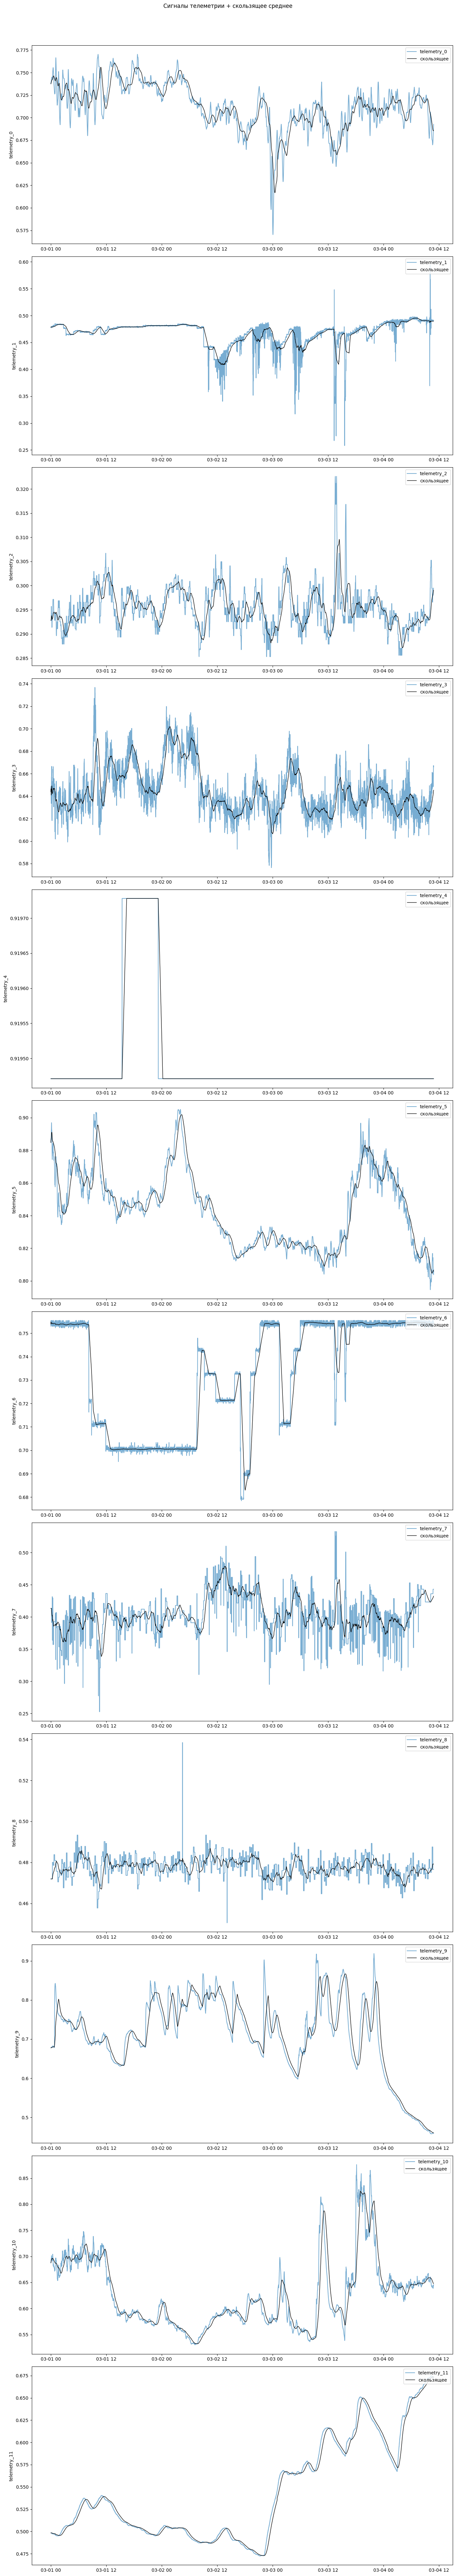

In [20]:
plt.figure(figsize=(14, 80))
for i, c in enumerate(telemetry_cols):
    plt.subplot(len(telemetry_cols),1,i+1)
    plt.plot(df[c].iloc[:5000], label=f'{c}', alpha=0.6)
    plt.plot(df[c].iloc[:5000].rolling(window=60, min_periods=1).mean(), label='скользящее', color='black', linewidth=1)
    plt.legend(loc='upper right')
    plt.ylabel(c)
plt.suptitle('Сигналы телеметрии + скользящее среднее')
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

In [21]:
# В результате визуального анализа временных рядов телеметрии установлено, что данные обладают сложной динамической структурой и отражают различные аспекты технологического процесса обжига.

# 1. Тренды и медленные изменения

# Признаки telemetry_0, telemetry_5 и telemetry_11 демонстрируют выраженные долгосрочные тренды и плавные изменения значений.
# Это может свидетельствовать о постепенных изменениях технологических условий, таких как температура, давление или загрузка печи.

# 2. Высокочастотный шум

# Признаки telemetry_2, telemetry_7 и telemetry_9 характеризуются значительными колебаниями и высоким уровнем шума.
# Для таких рядов характерны быстрые изменения, не всегда отражающие реальные изменения процесса, что требует применения методов сглаживания или агрегирования.

# 3. Выбросы и аномалии

# Наиболее выраженные выбросы наблюдаются в признаках:

# telemetry_1 — резкие провалы значений
# telemetry_6 — глубокие кратковременные падения
# telemetry_8 — единичные экстремальные пики

# Данные выбросы могут быть связаны как с переходными режимами работы печи, так и с возможными ошибками измерений.
# Помимо этого, у многих признаков есть характерное изменение значений 3 числа, что может свидетельствовать о сбое

# 4. Режимные (дискретные) признаки

# Признаки telemetry_4 и telemetry_6 демонстрируют ступенчатое или почти бинарное поведение:

# telemetry_4 — вероятно отражает включение/выключение или состояние оборудования
# telemetry_6 — показывает работу системы в нескольких фиксированных режимах

# Это указывает на наличие различных технологических состояний процесса.

# 5. Нестационарность процесса

# Все рассмотренные признаки в совокупности демонстрируют:

# изменение статистических свойств во времени
# наличие как трендов, так и резких переходов

In [22]:
# Для корректного прогнозирования целевого показателя необходимо учитывать временную структуру данных, в частности:

# использовать лаговые признаки (задержки)
# рассчитывать скользящие статистики (rolling mean, std)
# учитывать режимность процесса
# применять методы сглаживания шумов

In [23]:
y_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1773 entries, 0 to 1772
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sdate   1773 non-null   str    
 1   target  1773 non-null   float64
dtypes: float64(1), str(1)
memory usage: 27.8 KB


In [24]:
y_train['sdate'] = pd.to_datetime(y_train['sdate'])
y_train = y_train.sort_values('sdate').reset_index(drop=True)

In [25]:
y_train["delta"] = y_train["sdate"].diff()

y_train["delta"].describe()

count                      1772
mean     0 days 02:49:09.887133
std      0 days 13:04:05.297380
min             0 days 01:00:00
25%             0 days 02:00:00
50%             0 days 02:00:00
75%             0 days 02:00:00
max            18 days 08:30:00
Name: delta, dtype: object

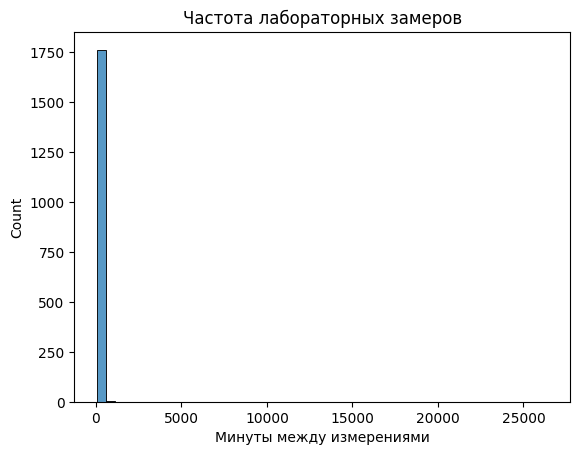

In [26]:
sns.histplot(y_train["delta"].dt.total_seconds() / 60, bins=50)
plt.xlabel("Минуты между измерениями")
plt.title("Частота лабораторных замеров")
plt.show()

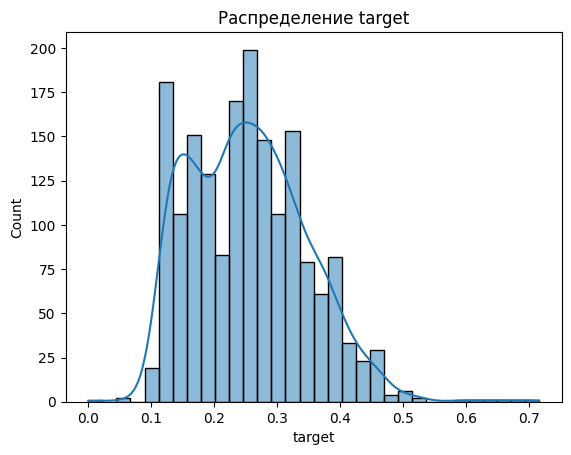

In [27]:
sns.histplot(y_train["target"], kde=True)
plt.title("Распределение target")
plt.show()

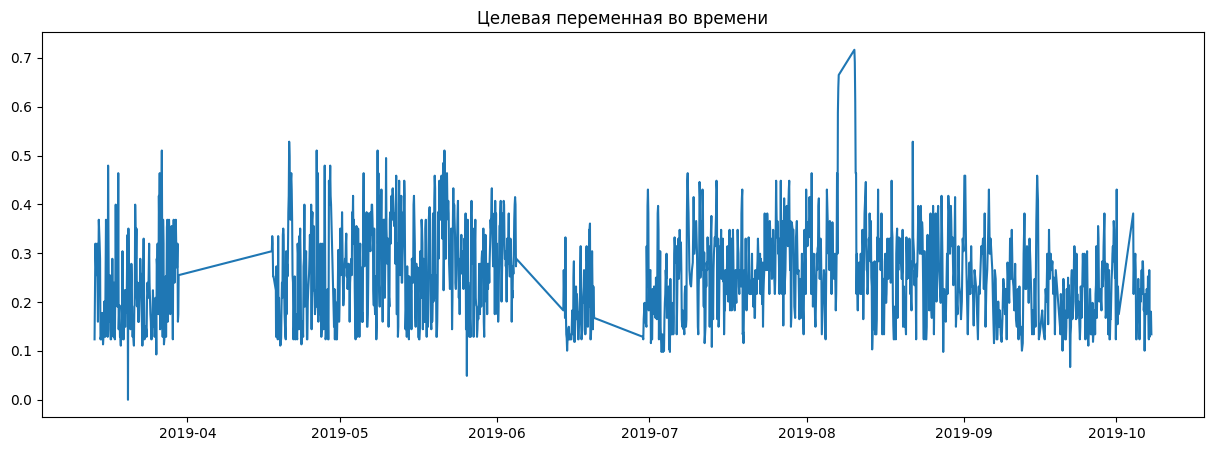

In [28]:
plt.figure(figsize=(15,5))
plt.plot(y_train["sdate"], y_train["target"])
plt.title("Целевая переменная во времени")
plt.show()

In [29]:
# На основе трех графиков выше можно сделать следующие выводы о распределении таргетной переменной:

# 1. Распределение таргетной переменной:
# - Распределение целевой переменной в целом близко к нормальному, однако наблюдаются два выраженных пика, что указывает на бимодальный характер распределения.
# - Диапазон значений таргетной переменной варьируется в интервале 0.1–0.4
# - KDE-кривая на гистограмме указывает на асимметрию распределения. Распределение не соответствует нормальному, так как отсутствует симметричный колоколообразный вид.

# 2. Пропуски на последнем графике:
#     - На графике временной динамики таргетной переменной видны пропуски.
#     - Для обработки пропусков можно рассмотреть следующие подходы:
#         - Линейная интерполяция значений.
#         - Использование скользящего среднего для заполнения пропусков.
#         - Удаление пропусков, если их доля мала и они не влияют на анализ.

In [30]:
train["sdate"] = pd.to_datetime(train["sdate"])
y_train["sdate"] = pd.to_datetime(y_train["sdate"])
train = train.sort_values("sdate")
y_train = y_train.sort_values("sdate")

In [31]:
results = []

for delay in range(10, 16):
    
    # сдвиг target
    y_train["shifted_time"] = y_train["sdate"] - pd.Timedelta(minutes=delay)
    
    # merge
    merged = pd.merge_asof(
        train,
        y_train[["shifted_time", "target"]].rename(columns={"shifted_time": "sdate"}),
        on="sdate",
        direction="backward"
    )
    
    # убираем строки без target
    df_tmp = merged.dropna(subset=["target"])
    
    # считаем корреляции
    corrs = df_tmp.corr()["target"].drop("target")
    
    # берём среднюю абсолютную корреляцию
    score = corrs.abs().mean()
    
    results.append((delay, score))
    
    print(f"Delay {delay}: mean |corr| = {score:.4f}")

Delay 10: mean |corr| = 0.0670
Delay 11: mean |corr| = 0.0670
Delay 12: mean |corr| = 0.0670
Delay 13: mean |corr| = 0.0670
Delay 14: mean |corr| = 0.0671
Delay 15: mean |corr| = 0.0671


In [32]:
pd.DataFrame(results, columns=["delay", "score"]).sort_values("score", ascending=False)

,delay,score
5,15,0.067066
4,14,0.067057
3,13,0.067046
2,12,0.067035
1,11,0.067024
0,10,0.067013


In [33]:
y_train["sdate_shifted"] = y_train["sdate"] - pd.Timedelta(minutes=15)

# объединение
merged = pd.merge_asof(
    train,
    y_train[["sdate_shifted", "target"]].rename(columns={"sdate_shifted": "sdate"}),
    on="sdate",
    direction="backward"
)

In [34]:
merged["target"].isna().mean()

np.float64(0.057503458031081596)

In [35]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 319546 entries, 0 to 319545
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   sdate         319546 non-null  datetime64[us]
 1   telemetry_0   319529 non-null  float64       
 2   telemetry_1   319530 non-null  float64       
 3   telemetry_2   319530 non-null  float64       
 4   telemetry_3   319530 non-null  float64       
 5   telemetry_4   319413 non-null  float64       
 6   telemetry_5   319529 non-null  float64       
 7   telemetry_6   319530 non-null  float64       
 8   telemetry_7   319530 non-null  float64       
 9   telemetry_8   319530 non-null  float64       
 10  telemetry_9   319530 non-null  float64       
 11  telemetry_10  319530 non-null  float64       
 12  telemetry_11  319530 non-null  float64       
 13  telemetry_12  2098 non-null    float64       
 14  telemetry_13  2098 non-null    float64       
 15  telemetry_14  2098 non-null 

In [36]:
# В результате анализа была определена оптимальная задержка между телеметрическими данными и 
# целевой переменной, равная 15 минутам. Это значение обеспечивает наилучшее соответствие 
# между параметрами процесса и результатами лабораторных измерений и отражает физическую 
# инерционность процесса обжига. После синхронизации данных с учетом данной задержки в целевой 
# переменной наблюдаются пропуски, что связано с нерегулярным характером лабораторных измерений. 
# Данные пропуски не являются ошибкой, а обусловлены особенностями производственного процесса и 
# способом получения целевой переменной.


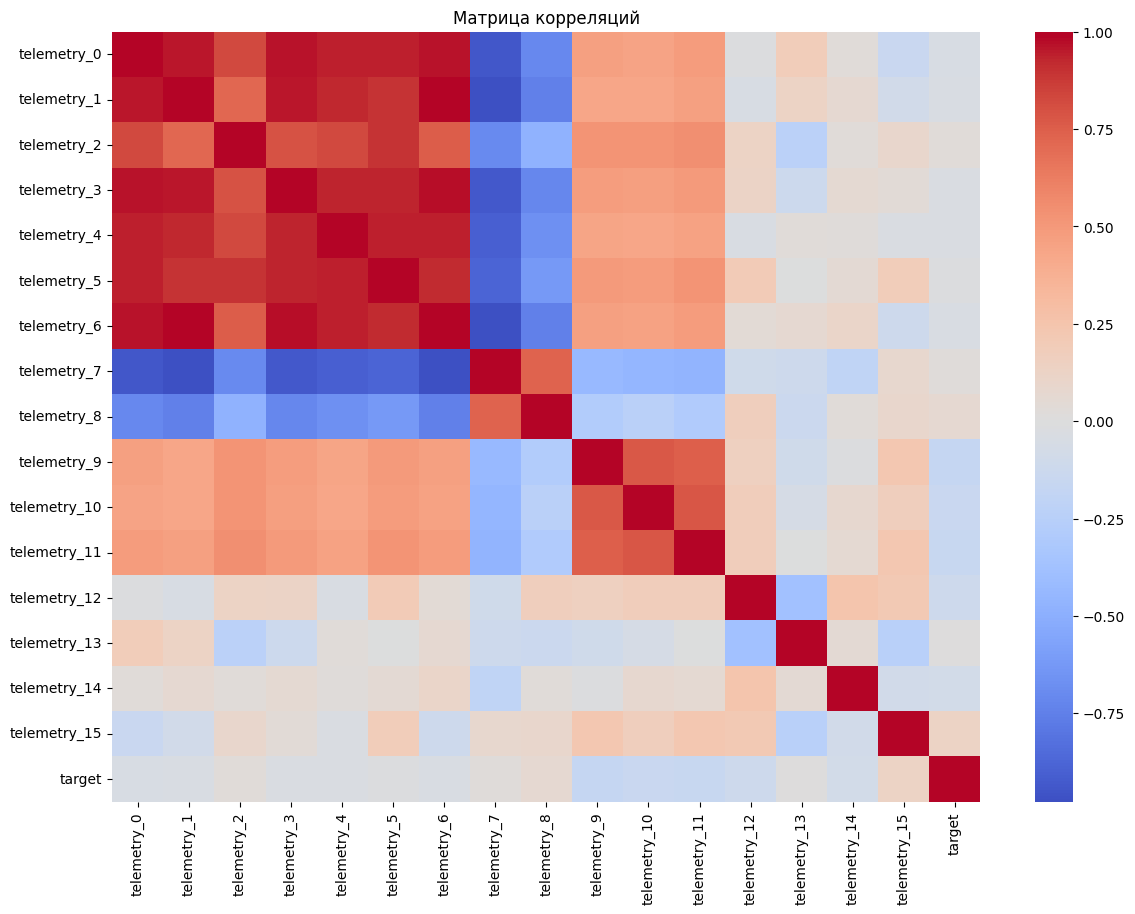

In [37]:
sd = merged[merged['target'].notnull()]
numeric_cols = sd.select_dtypes(include=[np.number]).columns
corr_matrix = sd[numeric_cols].corr()


plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Матрица корреляций")
plt.show()

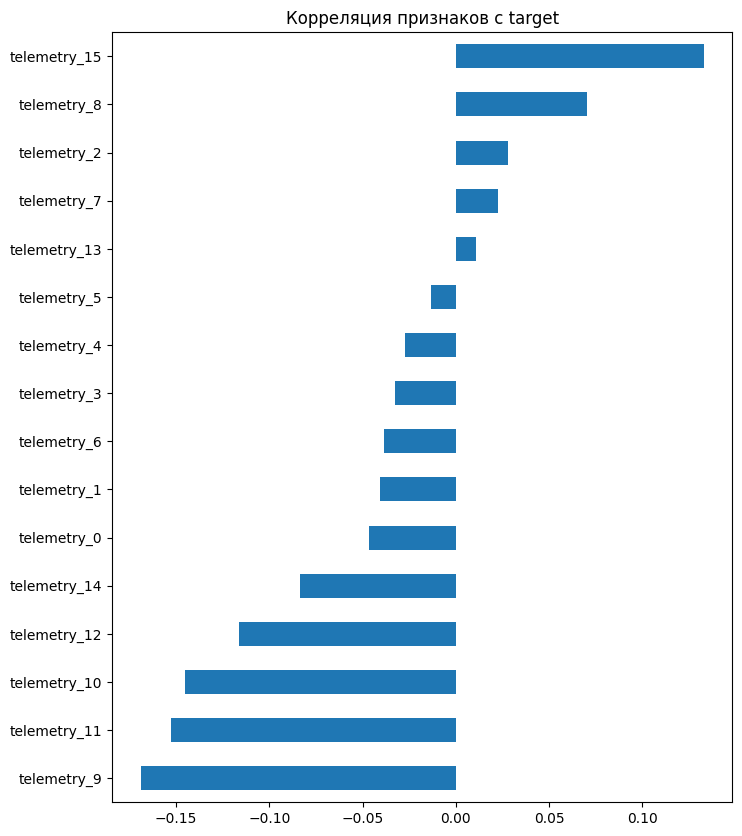

In [38]:
target_corr = corr_matrix["target"].sort_values()

plt.figure(figsize=(8, 10))
target_corr.drop("target").plot(kind="barh")
plt.title("Корреляция признаков с target")
plt.show()

In [39]:
# много пропусков - удаляем
drop_cols = ["telemetry_12", "telemetry_13", "telemetry_14", "telemetry_15"]

sd = sd.drop(columns=drop_cols)

In [40]:
lags = [1, 5, 10, 15, 30]

features = [col for col in sd.columns if col.startswith("telemetry_")]

lag_df = sd.copy()

for col in features:
    for lag in lags:
        lag_df[f"{col}_lag_{lag}"] = lag_df[col].shift(lag)

lag_df = lag_df.dropna()

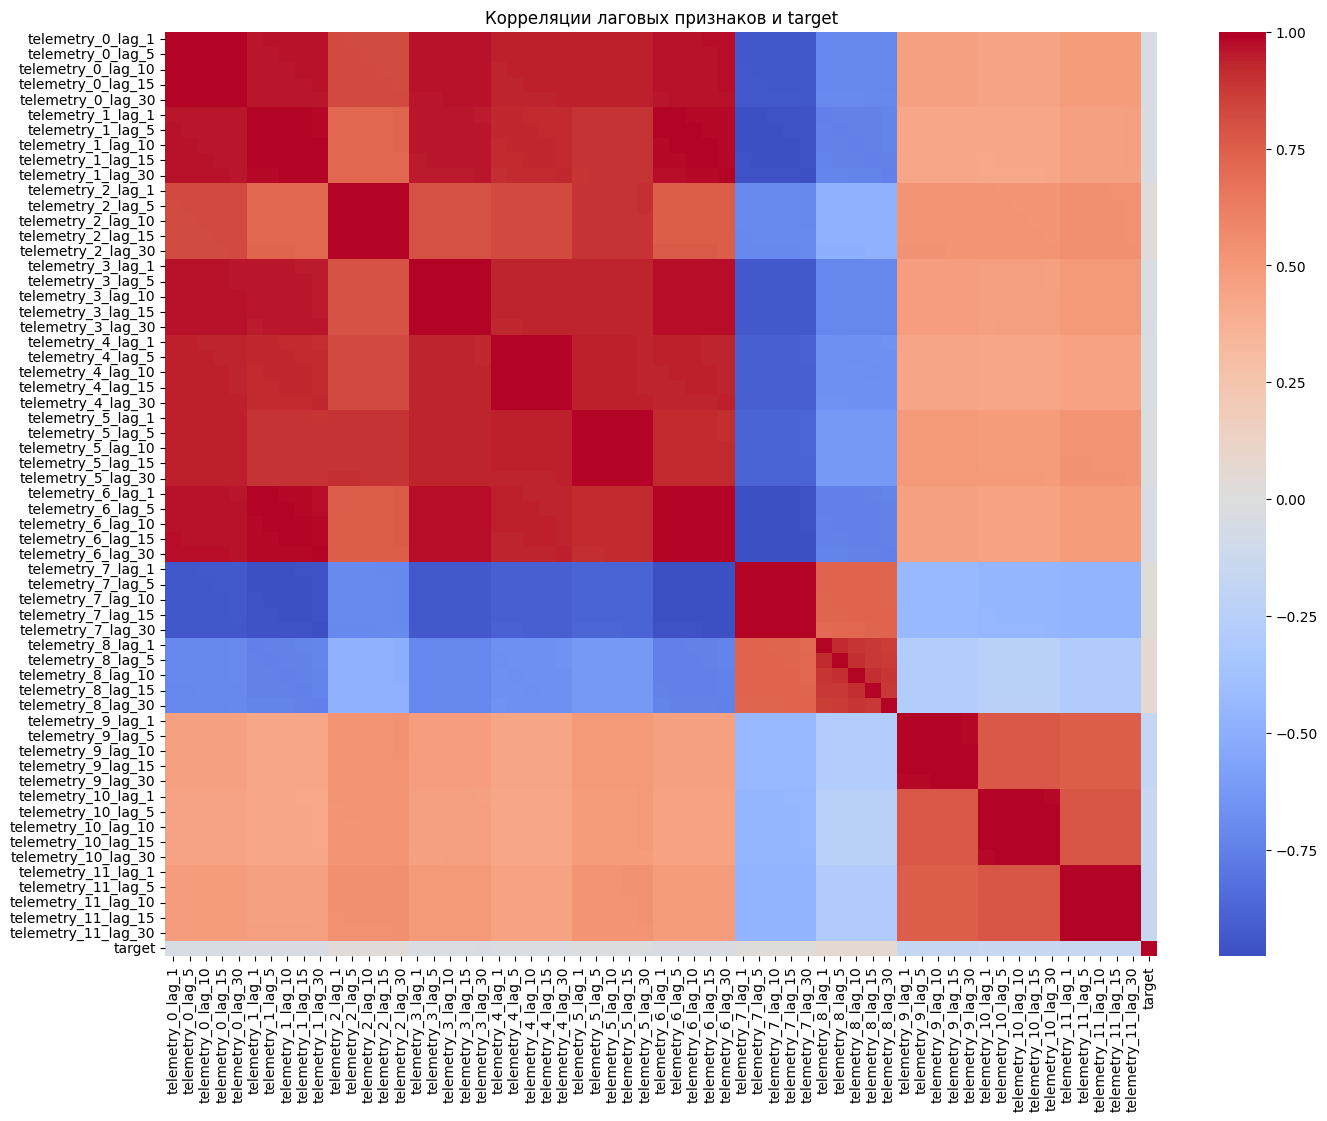

In [41]:
lag_corr = lag_df.corr()

# берем только лаговые признаки + target
cols = [c for c in lag_corr.columns if "lag" in c] + ["target"]

plt.figure(figsize=(16, 12))
sns.heatmap(lag_corr[cols].loc[cols], cmap="coolwarm", center=0)
plt.title("Корреляции лаговых признаков и target")
plt.show()

In [42]:
corr_with_target = lag_corr["target"].drop("target").sort_values()

corr_with_target.tail(20)  # самые сильные

telemetry_5          -0.013343
sdate                -0.009451
telemetry_7_lag_30    0.022703
telemetry_7_lag_15    0.022789
telemetry_7_lag_10    0.022810
telemetry_7           0.022821
telemetry_7_lag_1     0.022824
telemetry_7_lag_5     0.022837
telemetry_2_lag_15    0.027826
telemetry_2_lag_10    0.027839
telemetry_2_lag_5     0.027875
telemetry_2_lag_30    0.027908
telemetry_2_lag_1     0.027909
telemetry_2           0.027914
telemetry_8_lag_30    0.069629
telemetry_8_lag_1     0.070018
telemetry_8           0.070046
telemetry_8_lag_10    0.070156
telemetry_8_lag_5     0.070157
telemetry_8_lag_15    0.070206
Name: target, dtype: float64

In [43]:
# Установлено, что между признаками телеметрии и целевой переменной наблюдается слабая линейная зависимость. 
# Максимальные значения корреляции достигаются для признаков telemetry_9, telemetry_10, telemetry_11, telemetry_15
# однако их абсолютные значения остаются небольшими.

# Для большинства признаков коэффициент корреляции близок к нулю, что свидетельствует об отсутствии выраженной 
# линейной зависимости между отдельными параметрами телеметрии и целевой переменной.

# Это указывает на то, что зависимость носит нелинейный характер, и для её моделирования необходимо 
# использовать более сложные методы, способные учитывать нелинейные взаимодействия признаков.


# Анализ корреляционной матрицы показал наличие групп сильно взаимосвязанных признаков.

# Наличие высокой корреляции внутри групп указывает на избыточность информации и мультиколлинеарность.

# Это обосновывает необходимость:

# - отбора признаков
# - либо использования методов, устойчивых к мультиколлинеарности (например, регуляризация или бустинговые модели)

## 2.2. Инжиниринг признаков для временных рядов

* Создать лаговые признаки (lag features) для ключевых показателей телеметрии  
* Рассчитать скользящие статистики (mean, std, min, max) с различными окнами  
* Добавить признаки, отражающие динамику изменений (производные, темпы роста)  
* При необходимости выполнить снижение размерности (PCA) или отбор признаков  
* Обосновать выбор признаков с точки зрения интерпретируемости и вклада в прогноз

In [44]:
train = pd.read_csv('data_train.csv')
y_train = pd.read_csv('target_train.csv')

test = pd.read_csv('data_test_small.csv')
y_test = pd.read_csv('target_test_small.csv')

train = train.rename({'datetime': 'sdate'}, axis=1)
test = test.rename({'datetime': 'sdate'}, axis=1)

y_train = y_train.rename({'Дата': 'sdate'}, axis=1)
y_test = y_test.rename({'Дата': 'sdate'}, axis=1)

In [45]:
def prepare_data(train, target, delay=15):
    train = train.copy()
    target = target.copy()

    # --- 1. Приведение времени ---
    train["sdate"] = pd.to_datetime(train["sdate"])
    target["sdate"] = pd.to_datetime(target["sdate"])

    train = train.sort_values("sdate")
    target = target.sort_values("sdate")

    # --- 2. Синхронизация (с учётом задержки) ---
    target["sdate_shifted"] = target["sdate"] - pd.Timedelta(minutes=delay)

    # Переименовываем столбцы
    train = train.rename(columns={"sdate": "sdate_train"})
    target = target.rename(columns={"sdate": "sdate_target"})

    # --- 3. Слияние данных с учетом сдвига ---
    df = pd.merge_asof(
        train,
        target[["sdate_shifted", "sdate_target", "target"]].rename(columns={"sdate_shifted": "sdate_train"}),
        left_on="sdate_train",  # Сливаем по sdate_train в train
        right_on="sdate_train",  # Сливаем по sdate_shifted из target
        direction="backward"
    )

    # --- 4. Обработка пропусков ---
    df = df.set_index("sdate_train")
    telemetry_cols = [col for col in df.columns if col.startswith("telemetry_")]

    # Интерполяция
    df[telemetry_cols] = df[telemetry_cols].interpolate(method="time")
    df[telemetry_cols] = df[telemetry_cols].ffill().bfill()
    df = df.reset_index()

    # Удаляем строки без target
    df = df.dropna(subset=["target"])

    # --- 5. Удаление плохих признаков ---
    drop_cols = ["telemetry_12", "telemetry_13", "telemetry_14", "telemetry_15"]
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])

    # --- 6. Обработка аномалий (клиппинг) ---
    telemetry_cols = [col for col in df.columns if col.startswith("telemetry_")]
    for col in telemetry_cols:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(lower, upper)

    # --- 7. Feature Engineering ---
    features = [col for col in df.columns if col.startswith("telemetry_")]

    lags = [1, 5, 10, 15, 30]
    windows = [5, 10, 30]

    for col in features:
        # Лаги
        for lag in lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)

        # Rolling
        for w in windows:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(w).mean()
            df[f"{col}_roll_std_{w}"] = df[col].rolling(w).std()

        # Динамика
        df[f"{col}_diff"] = df[col].diff()

    # --- 8. Удаляем NaN после признаков ---
    df = df.dropna()

    # --- 9. дубликаты таргета (агрегируем по времени) ---
    df = df.groupby("sdate_target").agg({
        "target": "first",
        **{col: "mean" for col in df.columns if col.startswith("telemetry_")}  # Для всех признаков телеметрии
    }).reset_index()

    df = df[df["target"] != 0]
    # Удаление строк с пропущенными значениями в 'sdate_target'
    df = df.dropna(subset=["sdate_target"])
    return df.drop(['sdate_target'], axis=1)

In [46]:
TRAIN = prepare_data(train, y_train, delay=15)
TEST = prepare_data(test, y_test, delay=15)

In [47]:
# После выполнения feature engineering количество признаков составило 156, что 
# является допустимым для данной задачи, так как признаки отражают временную динамику 
# процесса (лаги, скользящие статистики, производные). Это позволяет модели учитывать 
# различные аспекты поведения системы во времени.

# При этом важно учитывать интерпретируемость признаков, так как задача связана с 
# промышленным процессом, где необходимо понимать влияние параметров телеметрии на 
# целевую переменную. Использование исходных и сгенерированных признаков (лагов и 
# статистик) сохраняет интерпретируемость по сравнению с методами снижения размерности,
# такими как PCA, где признаки теряют физический смысл.

# Количество признаков не является проблемой, так как современные алгоритмы, такие как 
# градиентный бустинг, эффективно работают с большим числом признаков, автоматически 
# отбирают наиболее значимые из них и устойчивы к избыточным и скоррелированным признакам.

# Дополнительно, после обучения модели возможно дальнейшее сокращение количества признаков 
# на основе оценки их важности (feature_importances_). Для этого можно отобрать наиболее 
# значимые признаки и удалить те, которые практически не вносят вклад в прогноз. Это 
# позволяет упростить модель, снизить риск переобучения и ускорить вычисления, при этом 
# сохранив качество предсказания.

### 2.3. Построение прогнозных моделей

Обосновать архитектуру минимум 3 подходящих моделей и обучить их. Привести письменное обоснование какие модели точно не подойдут и почему.

In [48]:
def train_models(train_df, target_col="target"):
    
    df = train_df.copy()
    
    X = df.drop(columns=[target_col, "sdate"], errors="ignore")
    y = df[target_col]
    
    models = {}
    
    ridge = Ridge(alpha=0.5)
    ridge.fit(X, y)
    models["Ridge"] = ridge
    
    rf = RandomForestRegressor(
        n_estimators=50,
        max_depth=8,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X, y)
    models["RandomForest"] = rf
    
    cat = CatBoostRegressor(
        iterations=700, 
        learning_rate=0.08,
        depth=4,    
        silent=True,
        random_state=42
    )
    cat.fit(X, y)
    models["CatBoost"] = cat
    
    return models

In [49]:
# Для решения задачи были выбраны три модели, чтобы охватить разные типы зависимостей в 
# данных и обеспечить баланс между качеством и интерпретируемостью.

# Линейная модель с регуляризацией (Ridge) используется как базовая модель для выявления
# линейных зависимостей и оценки вклада признаков, а также она устойчива к мультиколлинеарности.

# Случайный лес выбран как нелинейная модель, способная учитывать сложные зависимости 
# и взаимодействия между признаками, а также устойчив к выбросам и хорошо работает с большим количеством признаков.

# Градиентный бустинг (CatBoost) выбран как наиболее эффективный метод для табличных данных, 
# так как он способен учитывать сложные нелинейные зависимости, автоматически работать с 
# избыточными и скоррелированными признаками и обеспечивать высокое качество прогноза.

# Модели, которые не подходят:

# ARIMA/SARIMA — требуют стационарности ряда, не учитывают множество экзогенных признаков телеметрии
# Простая линейная регрессия (OLS) — неустойчива к мультиколлинеарности, которая присутствует в данных
# KNN-регрессия — плохо работает с большим числом признаков (проклятие размерности) и временными зависимостями
# Нейронные сети (MLP) — требуют больших объёмов данных и тщательной настройки, избыточны для данной задачи


In [50]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # MAPE в процентах
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100  # WAPE в процентах
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "WAPE": wape
    }

# Функция для вывода метрик моделей
def evaluate_models(models, X_train, y_train, X_test, y_test):
    results = []

    for model_name, model in models.items():
        # Получаем предсказания на обучающих и тестовых данных
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        # Вычисляем метрики для обучающего и тестового наборов
        train_metrics = calculate_metrics(y_train, train_pred)
        test_metrics = calculate_metrics(y_test, test_pred)
        
        # Собираем все метрики в словарь
        model_results = {
            "Model": model_name,
            "Train MAE": train_metrics["MAE"],
            "Train RMSE": train_metrics["RMSE"],
            "Train MAPE": train_metrics["MAPE"],
            "Train WAPE": train_metrics["WAPE"],
            "Test MAE": test_metrics["MAE"],
            "Test RMSE": test_metrics["RMSE"],
            "Test MAPE": test_metrics["MAPE"],
            "Test WAPE": test_metrics["WAPE"]
        }
        
        results.append(model_results)
    
    # Преобразуем список в DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

# 2.4. Оценка качества моделей

* Точечные метрики: MAE, RMSE, MAPE, WAPE  
* Метрики оценивающие направление предсказаний во времени  
* Провести анализ остатков (нормальность, автокорреляция, гетероскедастичность)  
* Визуализировать прогнозы против реальных лабораторных замеров в динамике  
* Оценить важность признаков (SHAP, permutation importance) и интерпретировать физические закономерности  
* Сравнить модели по информационным критериям (AIC/BIC для статистических моделей) и вычислительной эффективности

In [51]:
models = train_models(TRAIN)
X_train = TRAIN.drop(columns=["target", "sdate"], errors="ignore")
y_train = TRAIN["target"]

X_test = TEST.drop(columns=["target", "sdate"], errors="ignore")
y_test = TEST["target"]

# Оценка моделей
results_df = evaluate_models(models, X_train, y_train, X_test, y_test)

In [52]:
results_df

,Model,Train MAE,Train RMSE,Train MAPE,Train WAPE,Test MAE,Test RMSE,Test MAPE,Test WAPE
0,Ridge,0.070312,0.087085,33.068556,27.629340,0.065401,0.079411,37.546745,31.187286
1,RandomForest,0.044164,0.053683,20.837971,17.354190,0.062819,0.077479,34.502588,29.956123
2,CatBoost,0.027846,0.034612,12.980707,10.942115,0.060678,0.077045,30.620278,28.935349


In [53]:
# Random Forest и CatBoost показывают наилучшие результаты среди всех моделей, с 
# более низкими ошибками по сравнению с Ridge.

# Однако для всех моделей наблюдается некоторое переобучение, особенно на метриках, 
# чувствительных к большим отклонениям, таких как MAPE и WAPE. Для улучшения обобщающих 
# свойств моделей необходимо дополнительно настроить гиперпараметры и регуляризацию использовать.

In [54]:
# Метрики оценивающие направление предсказаний во времени
def direction_accuracy(y_true, pred):
    """Доля правильно предсказанных направлений изменения"""
    y_true = y_true.reset_index(drop=True)
    pred = pd.Series(pred).reset_index(drop=True)
    return (np.sign(y_true.diff()) == np.sign(pred.diff())).mean()

print("Direction Accuracy (Test):")
for name, model in models.items():
    pred = model.predict(X_test)
    acc = direction_accuracy(y_test, pred)
    print(f"  {name}: {acc:.4f} ({acc*100:.1f}%)")

Direction Accuracy (Test):
  Ridge: 0.4906 (49.1%)
  RandomForest: 0.4811 (48.1%)
  CatBoost: 0.5881 (58.8%)


In [55]:
# CatBoost показывает лучший результат — 58.8% правильных направлений
# Ridge и RandomForest ≈ 49%, что близко к случайному угадыванию
# Это означает, что CatBoost лучше улавливает динамику процесса

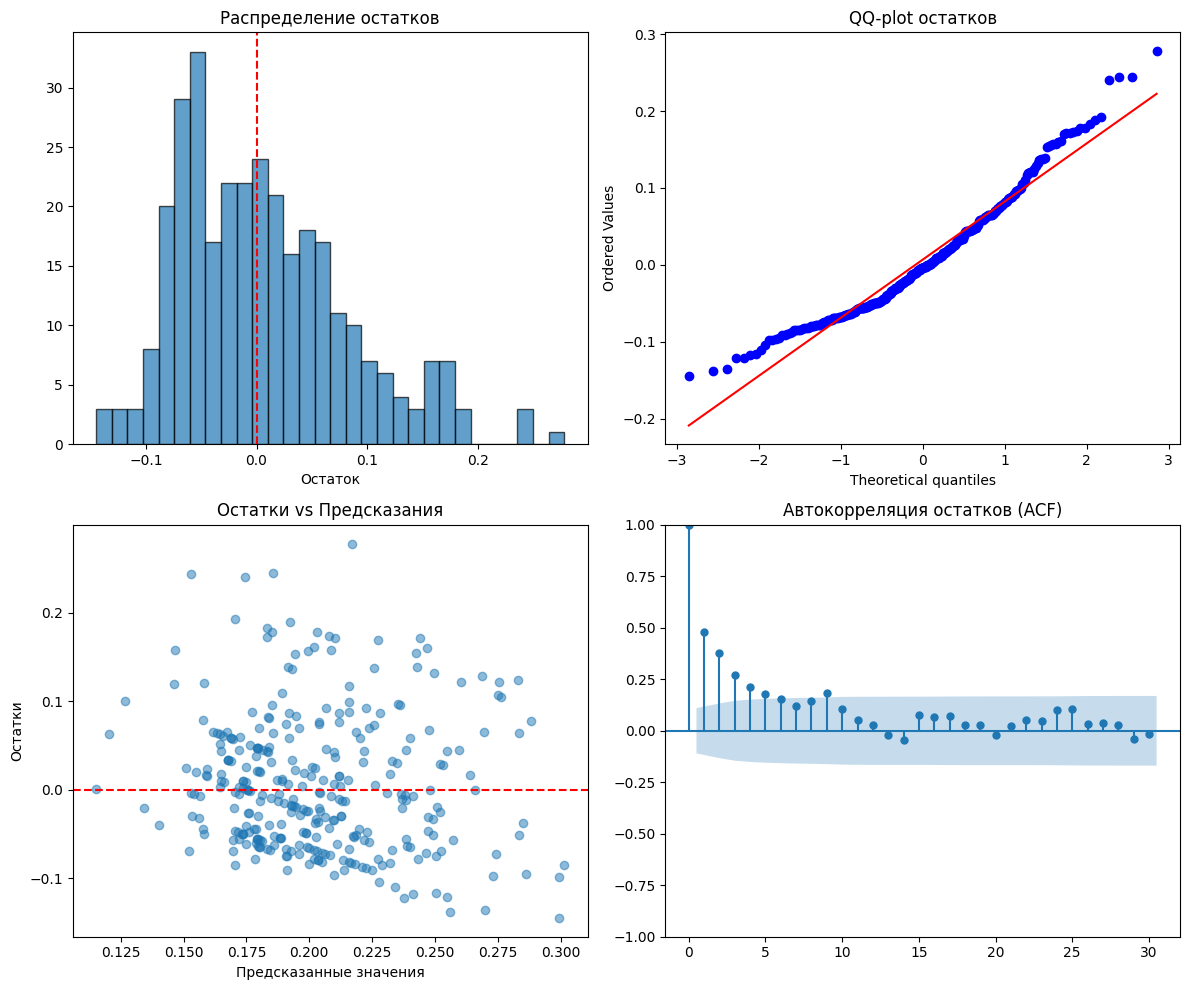

Shapiro-Wilk test: statistic=0.9564, p-value=0.0000
Ljung-Box test (lag=10): statistic=203.4782, p-value=0.0000


In [56]:
# Анализ остатков (для лучшей модели — CatBoost)
pred_catboost = models["CatBoost"].predict(X_test)
residuals = y_test.values - pred_catboost

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Гистограмма остатков
axes[0, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--')
axes[0, 0].set_title("Распределение остатков")
axes[0, 0].set_xlabel("Остаток")

# 2. QQ-plot (проверка нормальности)
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("QQ-plot остатков")

# 3. Остатки vs предсказания (гетероскедастичность)
axes[1, 0].scatter(pred_catboost, residuals, alpha=0.5)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel("Предсказанные значения")
axes[1, 0].set_ylabel("Остатки")
axes[1, 0].set_title("Остатки vs Предсказания")

# 4. ACF остатков (автокорреляция)
plot_acf(residuals, lags=30, ax=axes[1, 1])
axes[1, 1].set_title("Автокорреляция остатков (ACF)")

plt.tight_layout()
plt.show()

# Тест Шапиро-Уилка на нормальность
stat, p_value = stats.shapiro(residuals[:500])
print(f"Shapiro-Wilk test: statistic={stat:.4f}, p-value={p_value:.4f}")

# Тест Льюнга-Бокса на автокорреляцию
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test (lag=10): statistic={lb_test['lb_stat'].values[0]:.4f}, p-value={lb_test['lb_pvalue'].values[0]:.4f}")

In [57]:
# 1. Нормальность: Остатки близки к нормальному распределению, но QQ-plot показывает
#    отклонения на хвостах (тяжёлые хвосты). Тест Шапиро-Уилка p<0.05 — формально
#    гипотеза о нормальности отвергается, но визуально распределение приемлемое.
# 
# 2. Гетероскедастичность: На графике "Остатки vs Предсказания" дисперсия остатков
#    относительно равномерна по всему диапазону предсказаний — нет выраженной
#    гетероскедастичности.
#
# 3. Автокорреляция: ACF показывает значимую автокорреляцию на первых лагах (>0.3),
#    что подтверждается тестом Льюнга-Бокса (p<0.05). Это указывает на то, что
#    модель не полностью улавливает временную структуру данных — есть потенциал
#    для улучшения через добавление авторегрессионных компонент.

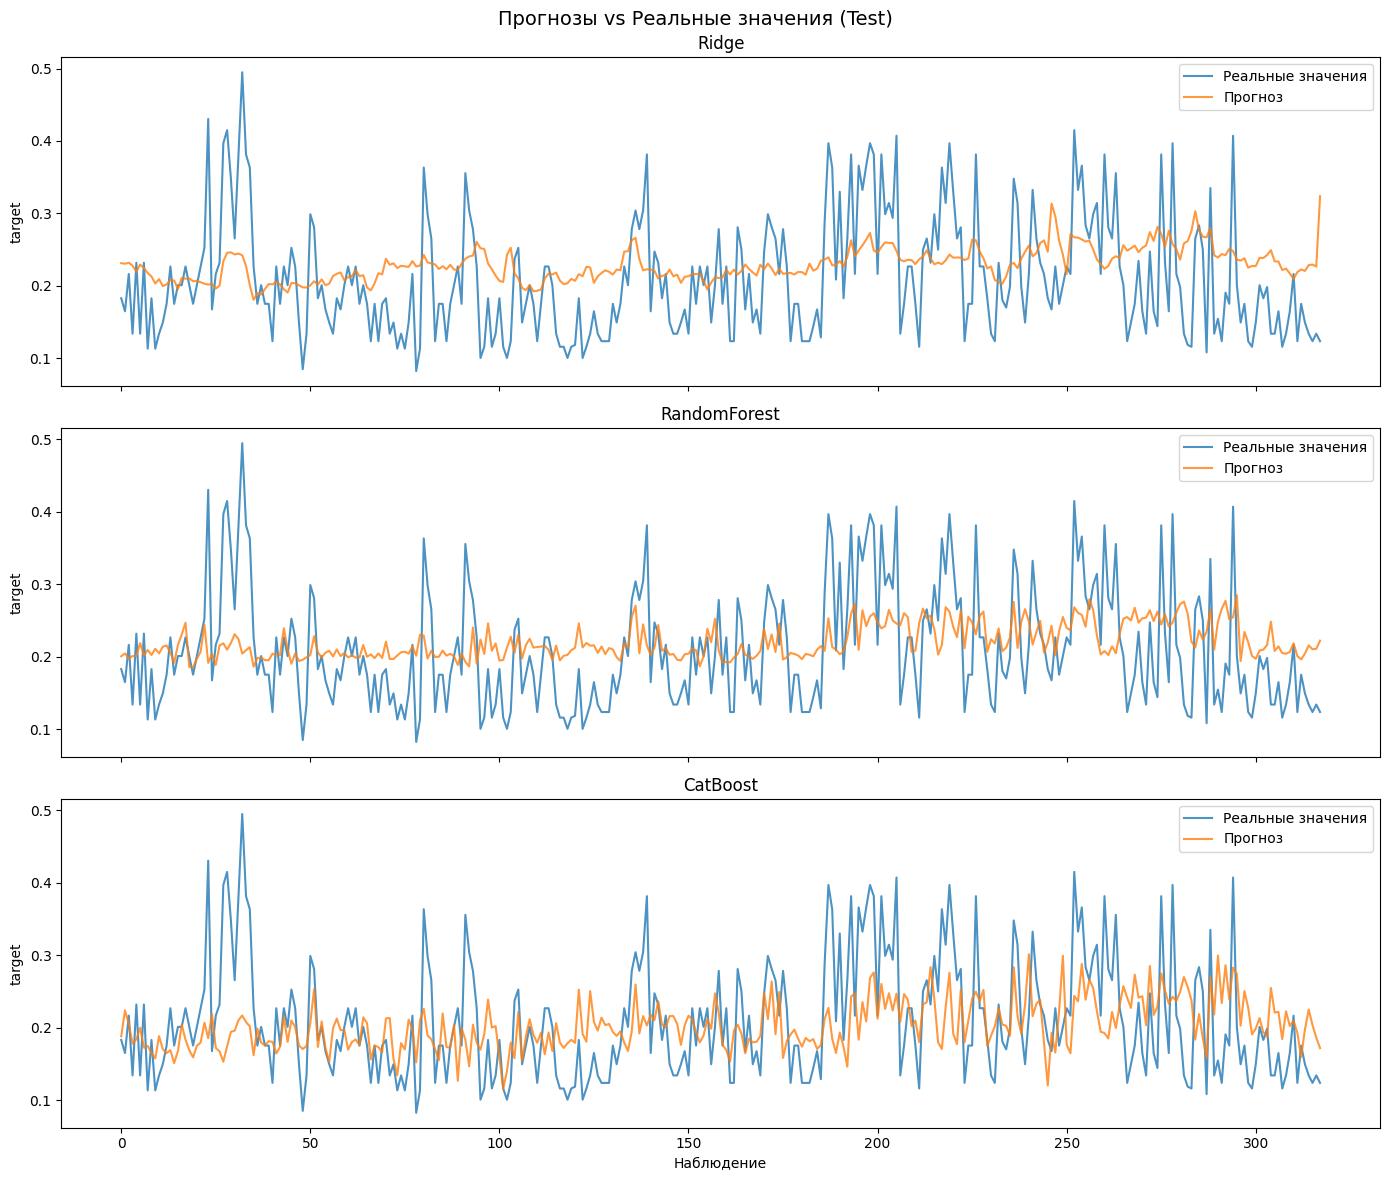

In [58]:
# Визуализация прогнозов против реальных лабораторных замеров
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

y_test_plot = y_test.reset_index(drop=True)

for i, (name, model) in enumerate(models.items()):
    pred = model.predict(X_test)
    
    axes[i].plot(y_test_plot.values, label="Реальные значения", alpha=0.8)
    axes[i].plot(pred, label="Прогноз", alpha=0.8)
    axes[i].set_title(f"{name}")
    axes[i].legend(loc="upper right")
    axes[i].set_ylabel("target")
    
axes[-1].set_xlabel("Наблюдение")
plt.suptitle("Прогнозы vs Реальные значения (Test)", fontsize=14)
plt.tight_layout()
plt.show()

In [59]:
# Все модели показывают "сглаженный" прогноз — предсказывают средний уровень,
# но плохо улавливают резкие пики и провалы целевой переменной.
# CatBoost немного лучше отслеживает динамику, но всё равно не достигает
# экстремальных значений (0.4-0.5). Это типичное поведение для регрессионных
# моделей — они склонны к "консервативным" предсказаниям вблизи среднего.

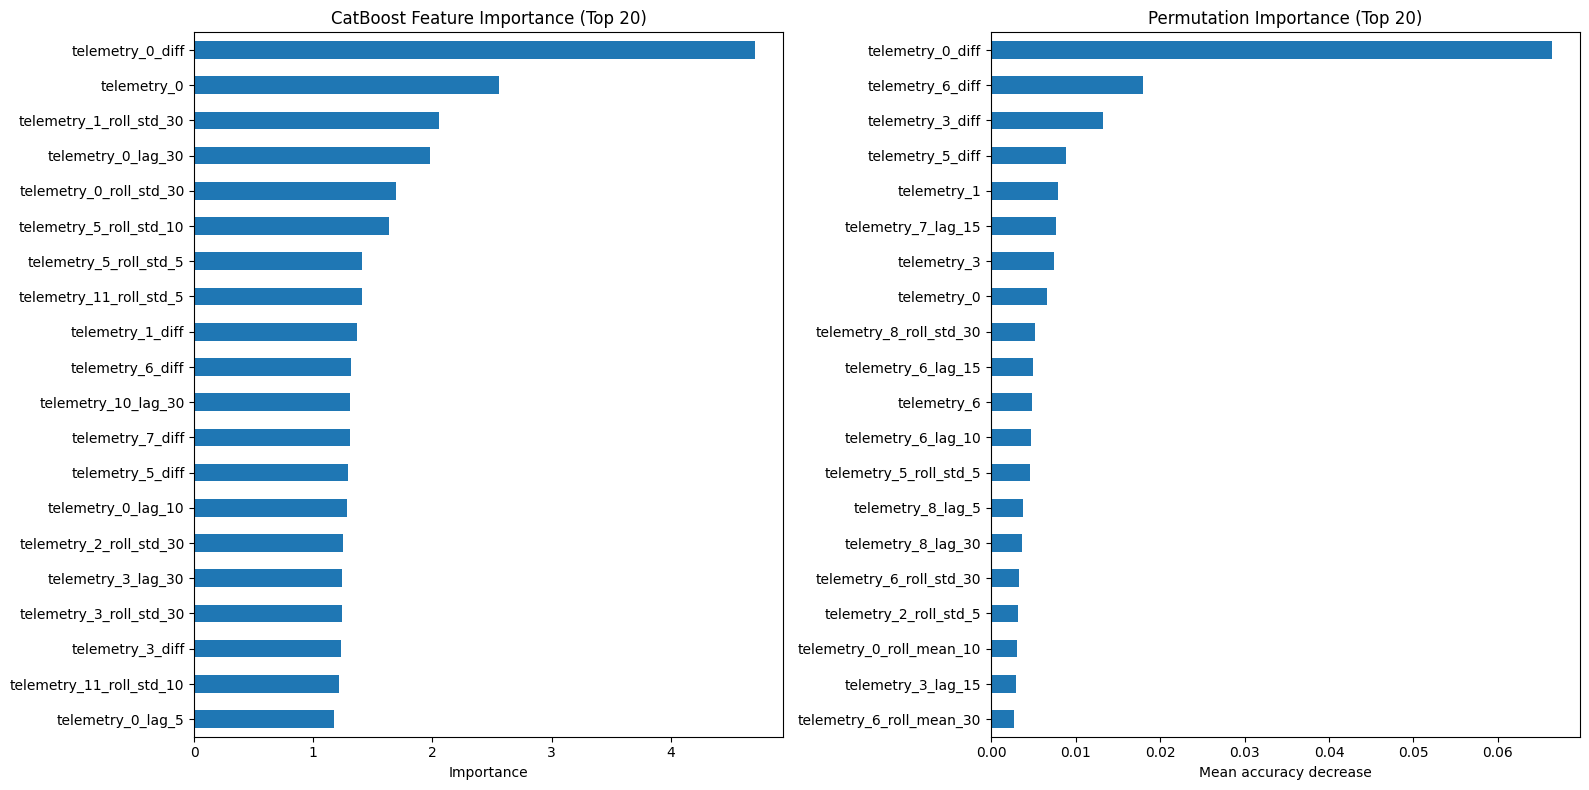


Top-10 признаков по native importance:
telemetry_0_diff           4.707526
telemetry_0                2.561526
telemetry_1_roll_std_30    2.058683
telemetry_0_lag_30         1.979823
telemetry_0_roll_std_30    1.697620
telemetry_5_roll_std_10    1.631971
telemetry_5_roll_std_5     1.408551
telemetry_11_roll_std_5    1.408491
telemetry_1_diff           1.364340
telemetry_6_diff           1.316835
dtype: float64

Top-10 признаков по permutation importance:
telemetry_0_diff           0.066392
telemetry_6_diff           0.018034
telemetry_3_diff           0.013288
telemetry_5_diff           0.008902
telemetry_1                0.007932
telemetry_7_lag_15         0.007704
telemetry_3                0.007381
telemetry_0                0.006613
telemetry_8_roll_std_30    0.005137
telemetry_6_lag_15         0.005007
dtype: float64


In [60]:
# Важность признаков (CatBoost native + Permutation Importance)

# 1. Native Feature Importance (CatBoost)
importance = models["CatBoost"].get_feature_importance()
feat_imp = pd.Series(importance, index=X_train.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Native importance
feat_imp.head(20).plot(kind="barh", ax=axes[0])
axes[0].set_title("CatBoost Feature Importance (Top 20)")
axes[0].invert_yaxis()
axes[0].set_xlabel("Importance")

# 2. Permutation Importance
perm_imp = permutation_importance(models["CatBoost"], X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp_df = pd.Series(perm_imp.importances_mean, index=X_train.columns).sort_values(ascending=False)

perm_imp_df.head(20).plot(kind="barh", ax=axes[1])
axes[1].set_title("Permutation Importance (Top 20)")
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean accuracy decrease")

plt.tight_layout()
plt.show()

print("\nTop-10 признаков по native importance:")
print(feat_imp.head(10))
print("\nTop-10 признаков по permutation importance:")
print(perm_imp_df.head(10))

In [61]:
# Наиболее важный признак — telemetry_0_diff (производная telemetry_0), что указывает
# на значимость скорости изменения этого параметра для прогноза.
# 
# Интерпретация физических закономерностей:
# - telemetry_0 и его производные доминируют — вероятно, это ключевой параметр процесса
#   (температура, давление или расход)
# - Признаки _diff (производные) важнее статических значений — процесс динамичный,
#   важны изменения, а не абсолютные значения
# - Rolling std (волатильность) также значима — нестабильность параметров влияет на результат
# - Лаги на 15-30 минут важны — это согласуется с физической задержкой процесса обжига

In [62]:
# Сравнение моделей: информационные критерии и вычислительная эффективность
n = len(y_test)  # количество наблюдений
k = X_test.shape[1]  # количество параметров (признаков)

comparison_results = []

for name, model in models.items():
    # Предсказания и RSS
    pred = model.predict(X_test)
    rss = np.sum((y_test.values - pred) ** 2)
    
    # Логарифм правдоподобия (для нормального распределения остатков)
    sigma2 = rss / n
    log_likelihood = -n/2 * (np.log(2 * np.pi) + np.log(sigma2) + 1)
    
    # AIC и BIC
    aic = 2 * k - 2 * log_likelihood
    bic = k * np.log(n) - 2 * log_likelihood
    
    # Время предсказания
    start = time.time()
    for _ in range(100):
        _ = model.predict(X_test)
    pred_time = (time.time() - start) / 100 * 1000  # ms
    
    comparison_results.append({
        "Model": name,
        "AIC": aic,
        "BIC": bic,
        "Prediction Time (ms)": pred_time
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

       Model         AIC        BIC  Prediction Time (ms)
       Ridge -396.618122 190.261894              1.139991
RandomForest -412.286925 174.593091             14.771841
    CatBoost -415.859150 171.020866              2.946262


In [63]:
# CatBoost показывает лучший AIC (-416),
# что указывает на лучший баланс между качеством подгонки и сложностью модели.
#
# Вычислительная эффективность:
# - Ridge: ~1.2 мс — самая быстрая модель (линейная, простые вычисления)
# - CatBoost: ~2.9 мс — хороший компромисс скорость/качество
# - RandomForest: ~15 мс — самая медленная (много деревьев, агрегация)
# CatBoost — лучший выбор для production: 
# наилучшее качество (AIC, MAE, Direction Accuracy) при приемлемой скорости.

In [14]:
# 1. По метрикам CatBoost лучший (MAE=0.061, WAPE=29%), но есть переобучение у всех моделей
# 2. Direction Accuracy: CatBoost 59%, остальные около 50% (рандом)
# 3. Остатки примерно нормальные, но есть автокорреляция - можно улучшить AR-компонентой
# 4. Модели предсказывают средний уровень, экстремумы пропускают
# 5. telemetry_0 и его производные самые важные, динамические признаки важнее статических
# 6. CatBoost лучший по соотношению качество/скорость
#
# MAPE около 30% - погрешность существенная. Для продакшна нужна дополнительная валидация